# Diabetes - Exploratory Data Analysis

Dataset: Pima Indians Diabetes Database (Kaggle - uciml/pima-indians-diabetes-database)

Goal: Understand the data before building any model - check for missing/zero values (this dataset has a known issue of 0s used as missing value placeholders), distributions, correlations, and class balance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
print('Shape:', df.shape)
print('\nColumn names:', df.columns.tolist())
df.info()

Shape: (768, 9)

Column names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Important: Zero Values as Hidden Missing Data

In this dataset, columns like Glucose, BloodPressure, SkinThickness, Insulin, and BMI cannot realistically be 0 for a living patient. A 0 in these columns usually means the value was not recorded, not that it's actually zero. We check this before doing any statistics or modeling.

In [3]:
zero_check_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_check_cols:
    zero_count = (df[col] == 0).sum()
    print(f'{col}: {zero_count} zero values ({zero_count/len(df)*100:.1f}%)')

Glucose: 5 zero values (0.7%)
BloodPressure: 35 zero values (4.6%)
SkinThickness: 227 zero values (29.6%)
Insulin: 374 zero values (48.7%)
BMI: 11 zero values (1.4%)


In [4]:
# Replace 0s with NaN for the affected columns so they get treated as missing data
df_clean = df.copy()
for col in zero_check_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)

print(df_clean.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [5]:
df_clean.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Target Variable Distribution (Outcome: 0 = No Diabetes, 1 = Diabetes)

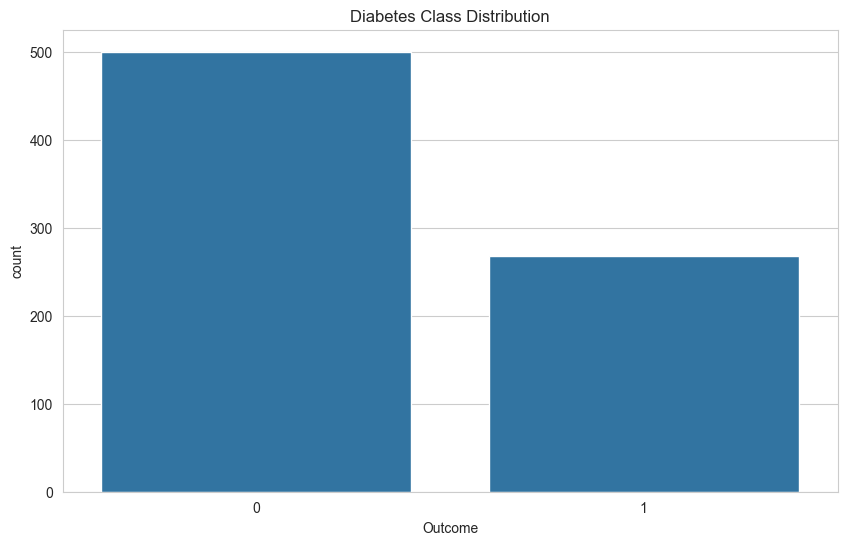

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [6]:
sns.countplot(x='Outcome', data=df_clean)
plt.title('Diabetes Class Distribution')
plt.show()

print(df_clean['Outcome'].value_counts(normalize=True))

## Numerical Feature Distributions

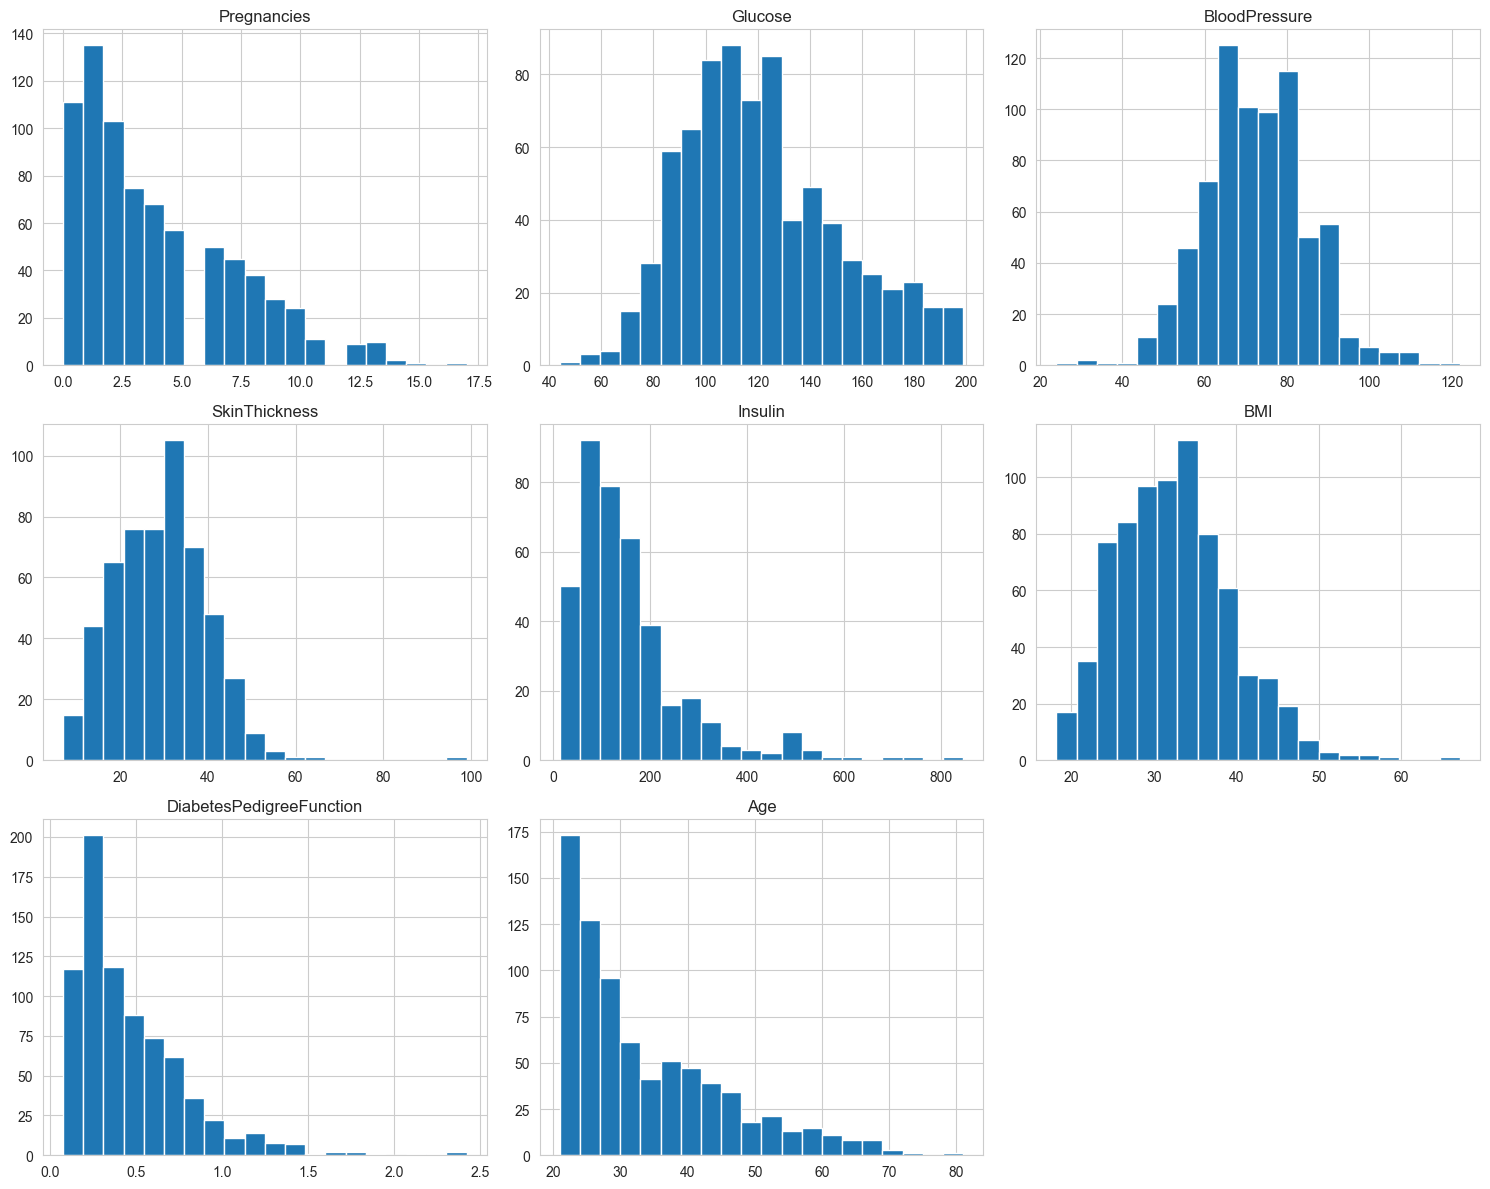

In [7]:
num_cols = [c for c in df_clean.columns if c != 'Outcome']
df_clean[num_cols].hist(bins=20, figsize=(15, 12))
plt.tight_layout()
plt.show()

## Correlation Heatmap

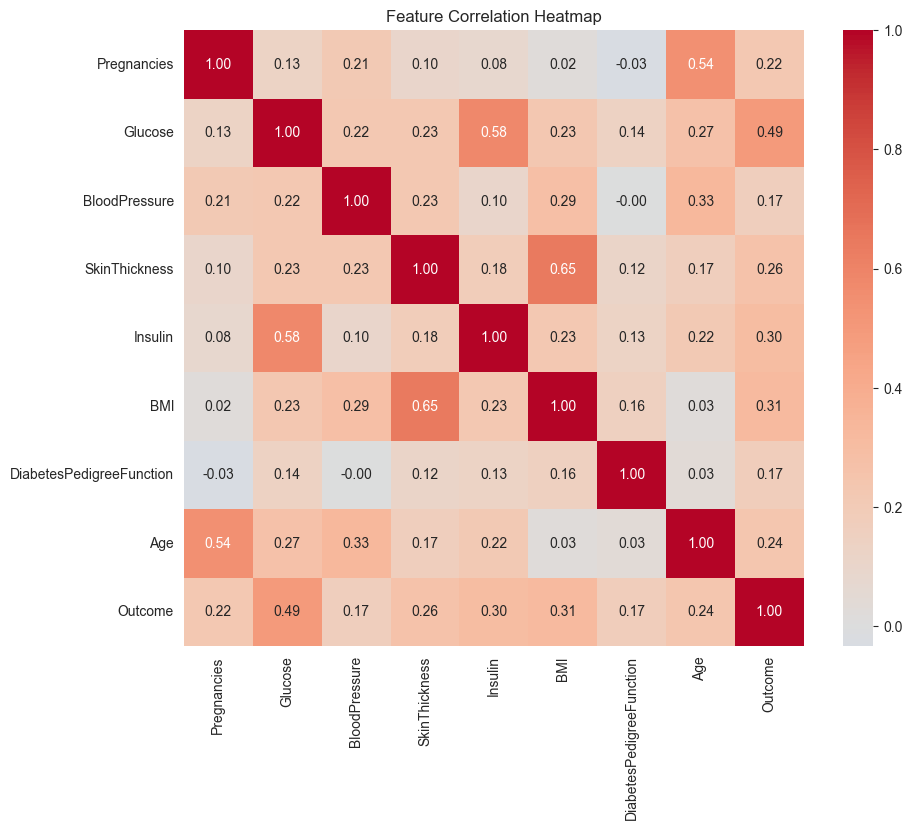

Outcome                     1.000000
Glucose                     0.494650
BMI                         0.313680
Insulin                     0.303454
SkinThickness               0.259491
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
BloodPressure               0.170589
Name: Outcome, dtype: float64


In [8]:
plt.figure(figsize=(10, 8))
corr = df_clean.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

print(corr['Outcome'].sort_values(ascending=False))

## Outlier Check

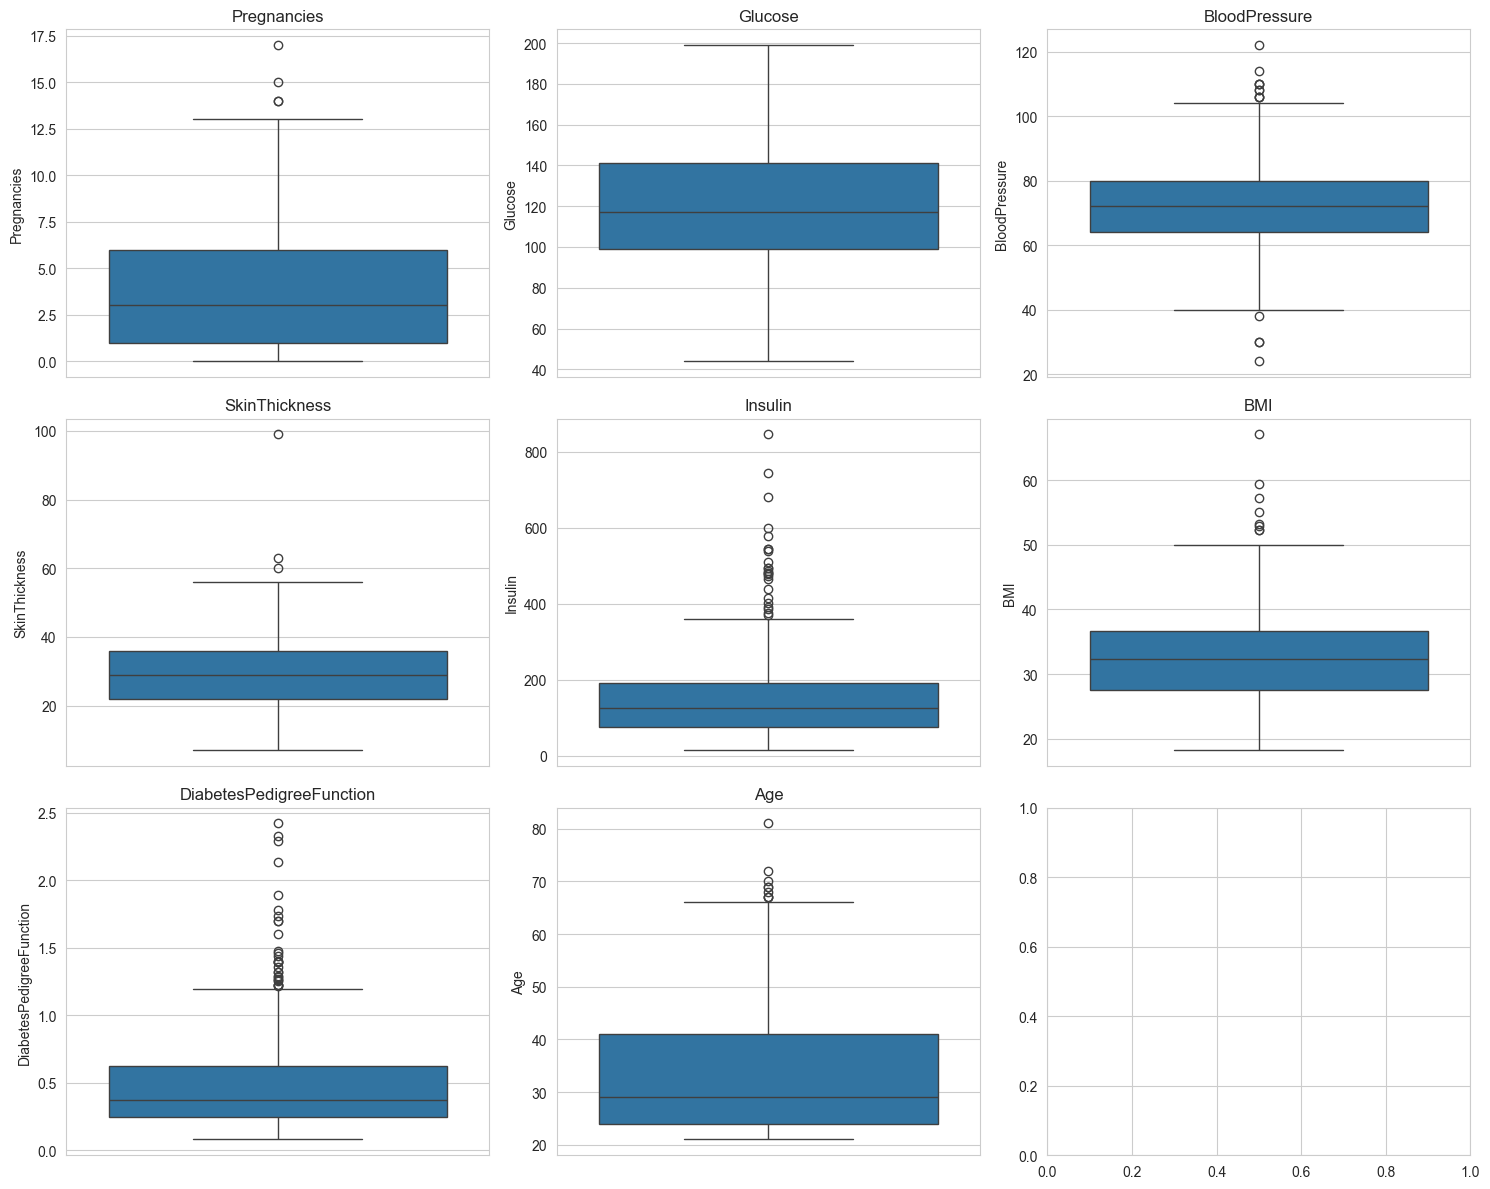

In [9]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(y=df_clean[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

## Key Takeaways (fill in after running)

- % of missing (originally zero) values per column: ...
- Class balance: ...
- Strongest predictors of diabetes based on correlation: ...
- Decision: impute missing values with median (safer than mean given skew) before modeling